In [ ]:
from utils import *
from FAPT import *
from DRAG import *
import matplotlib.pyplot as plt

rH = 1
rW = 1
use_gauss = True
s = Simulation()
dim_q1, dim_q2, dim_c = (3,3,3)

tg_sym = sp.Symbol("t_g", real=True, positive=True)
sigma_sym = sp.Symbol(r"\sigma", real=True, positive=True)
tsym = sp.Symbol("t", real=True, positive=True)

wd_sym = sp.Function(r"\omega_d", real=True)(tsym)
Ar_sym = sp.Function("A_r", real=True)(tsym)
Ai_sym = sp.Function("A_i", real=True)(tsym)
A_t_sym = Ar_sym + sp.I * Ai_sym

factor_gauss = sp.Symbol("f", real=True, positive=True)
A0, _ = gauss(tsym, factor_gauss, tg_sym, sigma_sym, True)
wd0 = sp.Symbol(r"\omega_{d,0}", real=True)


Create the effective Hamiltonian with symbolic dependencies

In [2]:
Heff_sym = Heff_Floquet_total_matrix_summed(rH=rH,wd=wd_sym,A=A_t_sym,resonances=s.resonances,E=s.E_array,V_posHarm=s.V1_dressed_array,                
    ref_state=getattr(s, 'ref_state', None),dwd=0,dA=0,t=tsym,analytics=True,include_geometric=False,include_micromotion=False,include_g_correction=False,verbose=False,rW=rW)
H_eff_raw = sp.Matrix(Heff_sym)
delta_shift = H_eff_raw[0, 0]
Heff = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])

Heff_sym_0 = Heff_Floquet_total_matrix_summed(rH=rH,wd=wd0,A=A0,resonances=s.resonances,E=s.E_array,V_posHarm=s.V1_dressed_array,                
    ref_state=getattr(s, 'ref_state', None),dwd=0,dA=0,t=tsym,analytics=True,include_geometric=False,include_micromotion=False,include_g_correction=False,verbose=False,rW=rW)
H_eff_raw = sp.Matrix(Heff_sym_0)
delta_shift = H_eff_raw[0, 0]
Heff0 = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])

In [7]:
# implement equations leading to drag:
Delta = Heff[2,2] - 2*Heff[1,1]
rrr = 0.1
dOab0_dt = Heff0[0,1].diff(tsym)

eq1 = sp.Eq(sp.re(Heff[0,1]),  Heff0[0,1])
eq2 = sp.Eq(sp.im(Heff[0,1]), -dOab0_dt/Delta)
eq3 = sp.Eq(Heff[1,1],(rrr**2-4)*Heff0[0,1]**2/(4*Delta))
Heff0[2,2]

7.70238999213076 - 2*\omega_{d,0}

In [4]:
# solving the equations
Ar_sol = sp.solve(eq1, Ar_sym)[0]
eq2 = eq2.subs({Ar_sym: Ar_sol})
Ai_sol = sp.solve(eq2, Ai_sym)
# eq3 = eq3.subs({Ar_sym: Ar_sol})
Ai_sol = sp.solve(eq2, Ai_sym)
wd_sol = sp.solve(eq3, wd_sym)
print("Ar: ")
display(Ar_sol)
print("Ai: ")
display(Ai_sol)
print("wd: ")
display(wd_sol)

Ar: 


f*exp(-0.125*(2.0*t - t_g)**2/\sigma**2) - f*exp(-0.125*t_g**2/\sigma**2)

Ai: 


[0.426004478685611*f*(2.0*t - t_g)*exp(-0.125*(2.0*t - t_g)**2/\sigma**2)/\sigma**2]

wd: 


[-9.58638215570719e-5*f**2*(exp(0.125*t_g**2/\sigma**2) - exp(0.125*(2.0*t - t_g)**2/\sigma**2))**2*exp(-0.25*t_g**2/\sigma**2 - 0.25*(2.0*t - t_g)**2/\sigma**2) + 4.43804328641986]

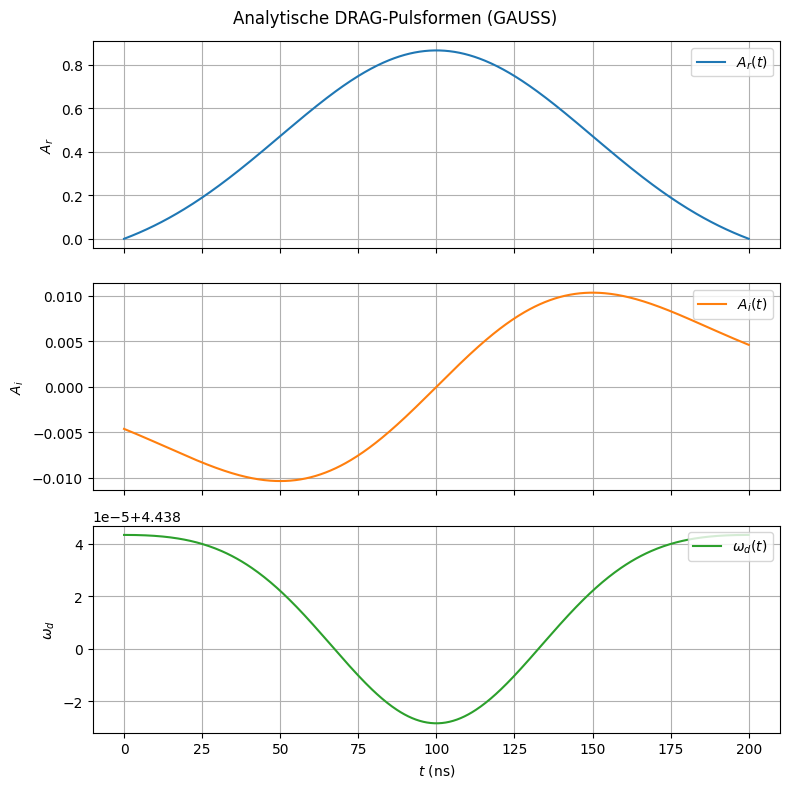

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Pulse Type wählen: gauss oder tanh
use_gauss = True  # True -> gauss, False -> tanh
pulse_name = "gauss" if use_gauss else "tanh"

# Beispielhafte Parameter für die numerische Auswertung
tg_val = 200.0          # Gatezeit in ns
sigma_val = tg_val / 4  # Sigma
f_val = 1.0             # Faktor f

t_num = np.linspace(0, tg_val, 500)

# Substitution der Parameter (ohne wd0)
subs_dict = {tg_sym: tg_val, sigma_sym: sigma_val, factor_gauss: f_val}

Ai_expr = Ai_sol[0] if isinstance(Ai_sol, (list, tuple)) else Ai_sol
wd_expr = wd_sol[0] if isinstance(wd_sol, (list, tuple)) else wd_sol

f_Ar = sp.lambdify(tsym, Ar_sol.subs(subs_dict), modules="numpy")
f_Ai = sp.lambdify(tsym, Ai_expr.subs(subs_dict), modules="numpy")
f_wd = sp.lambdify(tsym, wd_expr.subs(subs_dict), modules="numpy")

Ar_vals = np.vectorize(f_Ar)(t_num)
Ai_vals = np.vectorize(f_Ai)(t_num)
wd_vals = np.vectorize(f_wd)(t_num)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_num, Ar_vals, label=r"$A_r(t)$", color="tab:blue")
axes[0].set_ylabel(r"$A_r$")
axes[0].legend(loc="upper right")
axes[0].grid(True)

axes[1].plot(t_num, Ai_vals, label=r"$A_i(t)$", color="tab:orange")
axes[1].set_ylabel(r"$A_i$")
axes[1].legend(loc="upper right")
axes[1].grid(True)

axes[2].plot(t_num, wd_vals, label=r"$\omega_d(t)$", color="tab:green")
axes[2].set_ylabel(r"$\omega_d$")
axes[2].set_xlabel(r"$t$ (ns)")
axes[2].legend(loc="upper right")
axes[2].grid(True)

plt.suptitle(f"Analytische DRAG-Pulsformen ({pulse_name.upper()})")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import sympy as sp
import numpy as np

SAVE_DIRECTORY = Path("operational_res/analytical_drive_data")

def save_analytical_drive(pulse_type, pulse_data, save_directory=SAVE_DIRECTORY):
    save_directory = Path(save_directory)
    save_directory.mkdir(parents=True, exist_ok=True)

    file_path = save_directory / f"analytical_drive_{pulse_type}_data.npz"

    np.savez_compressed(
        file_path,
        pulse_type=pulse_type,
        Ar_srepr=sp.srepr(pulse_data["Ar"]),
        Ai_srepr=sp.srepr(pulse_data["Ai"]),
        wd_srepr=sp.srepr(pulse_data["wd"]),
    )

    print(f"Symbolische Pulsform gespeichert: '{file_path}'")
    return file_path

# Präpariere die Lösungsdaten für das gewählte Profil (gauss oder tanh)
pulse_type = f"aa_{pulse_name}"

Ai_symbolic = Ai_sol[0] if isinstance(Ai_sol, (list, tuple)) else Ai_sol
wd_symbolic = wd_sol[0] if isinstance(wd_sol, (list, tuple)) else wd_sol

pulse_data = {
    "Ar": Ar_sol,
    "Ai": Ai_symbolic,
    "wd": wd_symbolic,
}

saved_file_path = save_analytical_drive(pulse_type=pulse_type, pulse_data=pulse_data)

KeyError: 'wd0'